In [2]:
import getdist.plots as gdplt
# import cobaya
# from cobaya.yaml import yaml_load_file
# from cobaya.run import run
import numpy as np
# import os
# from scipy import stats
# import pandas as pd
# from cobaya.yaml import yaml_dump_file
# import shutil
# import subprocess
import matplotlib.pyplot as plt
# from getdist import MCSamples
from cobaya import load_samples

In [12]:
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

# DESI2 fullsky

### individual chains

In [3]:
path = r'C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI3_14bins\run1'

gd_sample = load_samples(path, to_getdist=True, skip=0.33)

In [6]:
# names = gd_sample.getParamNames().list()

In [7]:
names = ['omegam', 'hrdrag', 'w', 'wa']

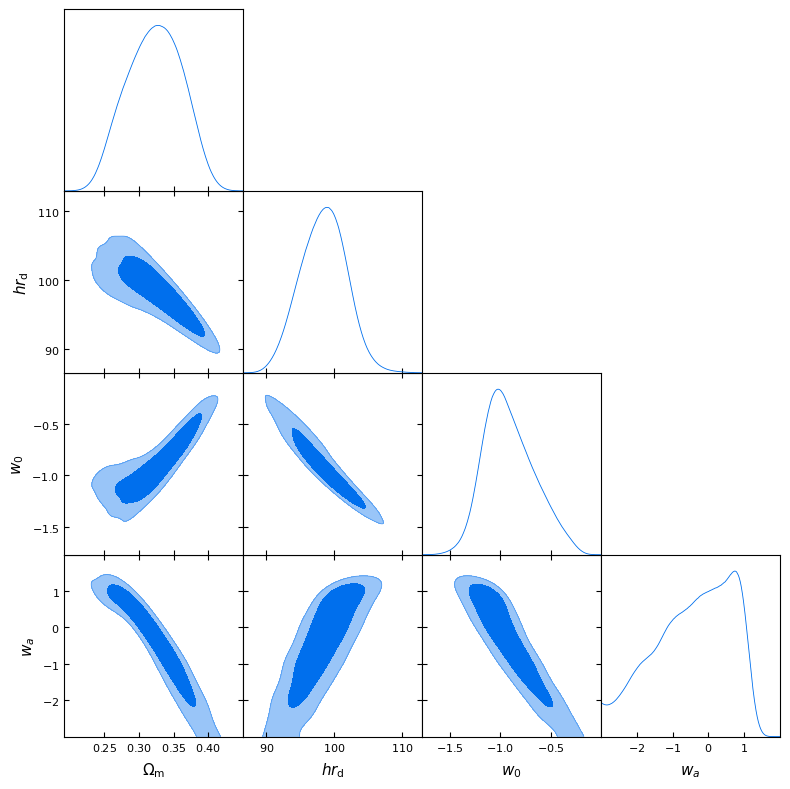

In [8]:
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, names, filled=True)

In [10]:
# Get effective sample size for all samples
eff_size = gd_sample.getEffectiveSamples()
print(f"Effective Sample Size: {eff_size}")

Effective Sample Size: 1593.134643722629


In [ ]:
# get means and covariance matrices
# for samp in gd_sample:
#     mean = samp.getMeans()[:2]
#     covmat = samp.getCovMat().matrix[:2, :2]
#     print("Mean:")
#     print(mean)
#     print("Covariance matrix:")
#     print(covmat)

#### $w_0 - w_a$ contours

In [ ]:
path_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point05\run1"
path_DESI_centered_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point01\DESI_centered\chain"
path_DESI_DR2 = r"C:\EPFL\MA4\code\old_stuff.bak\DESI_DR2_chains\base_w_wa\desi-bao-all\chain"
path_DESI_centered = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2\Rminus1_stop_point01\DESI_centered\chain"
path_DESI_correlated_centered = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2\Rminus1_stop_point01\DESI_correlated_centered\chain"
path_DESI_correlated_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point01\DESI_correlated_centered\chain"
path_DESI_nP1_fullsky = r"C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point01\DESI_nP=1\chain"

In [ ]:
from cobaya import load_samples

gd_sample = [load_samples(path_DESI_DR2, to_getdist=True, skip=0.33), load_samples(path_DESI_centered, to_getdist=True, skip=0.33), 
             load_samples(path_DESI_centered_fullsky, to_getdist=True, skip=0.33), load_samples(path_DESI_correlated_centered, to_getdist=True, skip=0.33),
             load_samples(path_DESI_correlated_fullsky, to_getdist=True, skip=0.33)]

names = ["hrdrag", "omm", "w", "wa"] 

# gdplot = gdplt.get_single_plotter()
# gdplot.settings.alpha_filled_add = 1
# gdplot.settings.alpha_factor_contour_lines = 1  
# gdplot.settings.linewidth_contour = 2.0
# gdplot.settings.num_plot_contours = 2
# gdplot.plot_2d(gd_sample, [names[1], names[2]], filled=True, width_inch=4, lims=[-3, 1, -3, 2])
# gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$"])
# gdplot.add_param_markers({names[1]: -1, names[2]: 0}, lw=1) 
# gdplot.export(f"figures/DESI_data/w_wa_individual/contours_w_wa_z{k}.png")

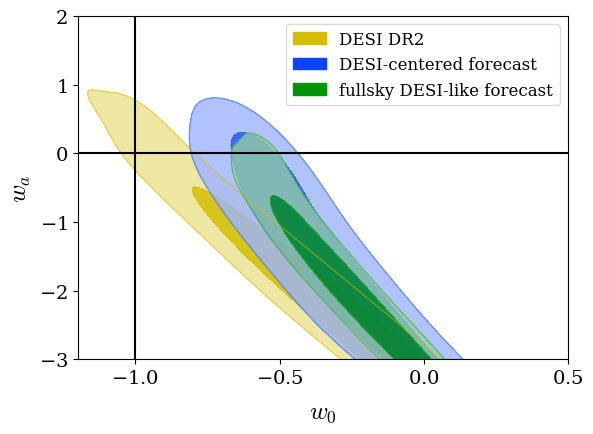

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

contour_colors = ['#d3be00', '#0b44ff', '#009407', '#c320c9']
gdplot.settings.solid_colors = contour_colors

# gdplot.plot_2d(gd_sample, 'w', 'wa',
#     filled=[True, True, True, False],
#     line_args=[
#         {'color': contour_colors[0]},
#         {'color': contour_colors[1]},
#         {'color': contour_colors[2]},
#         {'color': contour_colors[3], 'ls': '--'},
#     ]
# )
gdplot.plot_2d([gd_sample[i] for i in [0, 1, 2]], 'w', 'wa',
    filled=[True, True, True, True],
    line_args=[
        {'color': contour_colors[0]},
        {'color': contour_colors[1]},
        {'color': contour_colors[2]},
        {'color': contour_colors[3]}
    ],
    alphas=[0.9, 0.8, 0.75, 0.5, 0.5]
)

ax = gdplot.get_axes()

# x_fit = np.linspace(-2, 1, 100)

# c_mirage = "#FF0015"
# c_perp   = "#FF4800"
# c_para   = "#FF8800"
# c_nec    = 'b'
# c_steep  = 'k'

# ax.plot(x_fit, -3.66 * (x_fit + 1),    color=c_mirage, ls='-')
# ax.plot(x_fit,  3.66 * (x_fit + 1),    color=c_perp,   ls='--')
# ax.plot(x_fit, -3.66 * (x_fit + 0.8),  color=c_para,   ls='-.')
# ax.plot(x_fit, -1.0  * (x_fit + 1.0),  color=c_nec,    ls=':')
# ax.plot(x_fit, -6    * (x_fit + 1.0),  color=c_steep,  ls=':')

# ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)
ax.axhline(0,  color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

# legend_handles = [
#     mpatches.Patch(color=contour_colors[1], label='DESI+CMB+Pantheon+'),
#     mpatches.Patch(color=contour_colors[0], label='DESI+CMB+Union3'),
#     mpatches.Patch(color=contour_colors[2], label='DESI+CMB+DESY5'),
#     mlines.Line2D([], [], color=contour_colors[3], ls='--',
#                   label=r'DESI+CMB'),
#     mlines.Line2D([], [], color=c_mirage, ls='-',
#                   label=r'Mirage $\simeq -3.66(w_0+1)$'),
#     mlines.Line2D([], [], color=c_perp,   ls='--',
#                   label=r'$\perp$: $w_a = 3.66(w_0+1)$'),
#     mlines.Line2D([], [], color=c_para,   ls='-.',
#                   label=r'$\parallel$: $w_a = -3.66(w_0+0.8)$'),
#     mlines.Line2D([], [], color=c_nec,    ls=':',
#                   label=r'NEC: $w_a = -(w_0+1)$'),
#     mlines.Line2D([], [], color=c_steep,  ls=':',
#                   label=r'$w_a = -6(w_0+1)$')#,
# ]

legend_handles = [
    mpatches.Patch(color=contour_colors[0], label='DESI DR2'),
    mpatches.Patch(color=contour_colors[1], label='DESI-centered forecast'),
    mpatches.Patch(color=contour_colors[2], label='fullsky DESI-like forecast')#,
    # mpatches.Patch(color=contour_colors[3], label='DESI-correlated forecast')
    ]

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7)

ax.set_xlim(-1.2, 0.5)
ax.set_ylim(-3, 2)

fig = gdplot.fig
path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
# fig.savefig(path_to_fig + r'\forecast\w_wa_fullsky_DESI_centered.png', dpi=300)

In [37]:
path_14bins_DESIlike = r'C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI3_14bins\LCDM_centered\run1'
path_DESI_DR2 = r'C:\EPFL\MA4\code\old_stuff.bak\cobaya_test_runs\base_w_wa\LCDM_fakedata_not_random_1'
path_fullsky = r'C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI2_fullsky\Rminus1_stop_point01\LCDM_centered\run1'
path_nP1_fullsky = r'C:\EPFL\MA4\code\PDM2026\forecast_chains\w_wa\DESI3nP=1_fullsky\LCDM_centered\LCDM_centered'

In [38]:
from cobaya import load_samples

gd_sample = [load_samples(path_DESI_DR2, to_getdist=True, skip=0.33), load_samples(path_14bins_DESIlike, to_getdist=True, skip=0.33), 
             load_samples(path_fullsky, to_getdist=True, skip=0.33), load_samples(path_nP1_fullsky, to_getdist=True, skip=0.33)]#,
            #  load_samples(path_DESI_correlated_fullsky, to_getdist=True, skip=0.33)]

names = ["hrdrag", "omm", "w", "wa"] 

# gdplot = gdplt.get_single_plotter()
# gdplot.settings.alpha_filled_add = 1
# gdplot.settings.alpha_factor_contour_lines = 1  
# gdplot.settings.linewidth_contour = 2.0
# gdplot.settings.num_plot_contours = 2
# gdplot.plot_2d(gd_sample, [names[1], names[2]], filled=True, width_inch=4, lims=[-3, 1, -3, 2])
# gdplot.add_legend([r"$z_\mathrm{eff}=" + str(z) + r"$"])
# gdplot.add_param_markers({names[1]: -1, names[2]: 0}, lw=1) 
# gdplot.export(f"figures/DESI_data/w_wa_individual/contours_w_wa_z{k}.png")

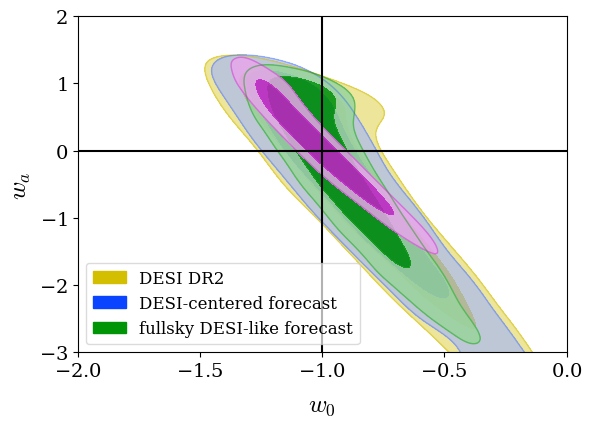

In [39]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

contour_colors = ['#d3be00', '#0b44ff', '#009407', '#c320c9']
gdplot.settings.solid_colors = contour_colors

# gdplot.plot_2d(gd_sample, 'w', 'wa',
#     filled=[True, True, True, False],
#     line_args=[
#         {'color': contour_colors[0]},
#         {'color': contour_colors[1]},
#         {'color': contour_colors[2]},
#         {'color': contour_colors[3], 'ls': '--'},
#     ]
# )
gdplot.plot_2d([gd_sample[i] for i in [0, 1, 2, 3]], 'w', 'wa',
    filled=[True, True, True, True],
    line_args=[
        {'color': contour_colors[0]},
        {'color': contour_colors[1]},
        {'color': contour_colors[2]},
        {'color': contour_colors[3]}
    ],
    alphas=[1, 0.6]
)

ax = gdplot.get_axes()

# x_fit = np.linspace(-2, 1, 100)

# c_mirage = "#FF0015"
# c_perp   = "#FF4800"
# c_para   = "#FF8800"
# c_nec    = 'b'
# c_steep  = 'k'

# ax.plot(x_fit, -3.66 * (x_fit + 1),    color=c_mirage, ls='-')
# ax.plot(x_fit,  3.66 * (x_fit + 1),    color=c_perp,   ls='--')
# ax.plot(x_fit, -3.66 * (x_fit + 0.8),  color=c_para,   ls='-.')
# ax.plot(x_fit, -1.0  * (x_fit + 1.0),  color=c_nec,    ls=':')
# ax.plot(x_fit, -6    * (x_fit + 1.0),  color=c_steep,  ls=':')

# ax.fill_between(x_fit, -x_fit, 3, color='gray', alpha=0.5)
ax.axhline(0,  color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

# legend_handles = [
#     mpatches.Patch(color=contour_colors[1], label='DESI+CMB+Pantheon+'),
#     mpatches.Patch(color=contour_colors[0], label='DESI+CMB+Union3'),
#     mpatches.Patch(color=contour_colors[2], label='DESI+CMB+DESY5'),
#     mlines.Line2D([], [], color=contour_colors[3], ls='--',
#                   label=r'DESI+CMB'),
#     mlines.Line2D([], [], color=c_mirage, ls='-',
#                   label=r'Mirage $\simeq -3.66(w_0+1)$'),
#     mlines.Line2D([], [], color=c_perp,   ls='--',
#                   label=r'$\perp$: $w_a = 3.66(w_0+1)$'),
#     mlines.Line2D([], [], color=c_para,   ls='-.',
#                   label=r'$\parallel$: $w_a = -3.66(w_0+0.8)$'),
#     mlines.Line2D([], [], color=c_nec,    ls=':',
#                   label=r'NEC: $w_a = -(w_0+1)$'),
#     mlines.Line2D([], [], color=c_steep,  ls=':',
#                   label=r'$w_a = -6(w_0+1)$')#,
# ]

legend_handles = [
    mpatches.Patch(color=contour_colors[0], label='DESI DR2'),
    mpatches.Patch(color=contour_colors[1], label='DESI-centered forecast'),
    mpatches.Patch(color=contour_colors[2], label='fullsky DESI-like forecast')#,
    # mpatches.Patch(color=contour_colors[3], label='DESI-correlated forecast')
    ]

ax.legend(handles=legend_handles, fontsize=12, framealpha=0.7, loc='lower left')

ax.set_xlim(-2, 0.0)
ax.set_ylim(-3, 2)

fig = gdplot.fig
path_to_fig = r'C:\EPFL\MA4\code\PDM2026\figures'
# fig.savefig(path_to_fig + r'\forecast\w_wa_fullsky_DESI_centered.png', dpi=300)